In [17]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [18]:
from datetime import datetime

In [19]:
import arcgis
from arcgis.features import FeatureCollection, FeatureSet
from arcgis.gis import Item
from arcgis.geoprocessing._job import GPJob

In [20]:
from arcgis.gis import GIS
gis = GIS(username="arcgis_python", password="amazing_arcgis_123", profile='your_online_profile', verify_cert=False) 

In [21]:
from arcgis.features.hydrology import watershed

In [22]:
chennai_lakes = gis.content.get('aea4f9362ea44759a5587a03b161d0ee')

<Item title:"ChennaiLakes" type:Feature Layer Collection owner:api_data_owner>
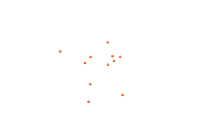

In [23]:
chennai_lakes

In [24]:
lakes_lyr = chennai_lakes.layers[0]

In [25]:
fs = lakes_lyr.query()

In [26]:
lakes_watersheds_test1 = watershed(input_points=fs, snap_distance=10, snap_distance_units='Meters',
              source_database='Finest', generalize=False, return_snapped_points=False)

In [27]:
assert isinstance(lakes_watersheds_test1.watershed_area, FeatureSet)
assert lakes_watersheds_test1.snapped_points is None

In [28]:
lakes_watersheds_test2 = watershed(input_points=fs, snap_distance=10, snap_distance_units='Meters',
              source_database='Finest', generalize=False, return_snapped_points=True)
lakes_watersheds_test2

ToolOutput(watershed_area=<FeatureSet> 11 features, snapped_points=<FeatureSet> 11 features)

In [29]:
assert isinstance(lakes_watersheds_test2.watershed_area, FeatureSet)
assert isinstance(lakes_watersheds_test2.snapped_points, FeatureSet)